# 04 - Sensitivity Analysis and Benchmark Comparisons

This notebook answers the next project question: **when does correlation misspecification actually matter?**

It does three things:

- builds a clean benchmark matrix for `true world` vs `hedger model`,
- sweeps the stress-correlation level, holding the rest fixed,
- sweeps regime persistence while keeping the long-run stress share fixed.

The emphasis is on hedging risk metrics rather than on mean P&L, because mean P&L can be contaminated by small initial pricing differences.

This version also makes the stress-correlation result more robust by repeating each high-stress scenario across multiple random seeds and summarizing the average hedge-performance gap.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

bundle = np.load(data_dir / "synthetic_market_data.npz")
asset_parameters = pd.read_csv(data_dir / "asset_parameters.csv", index_col=0)
market_settings = pd.read_csv(data_dir / "market_settings.csv", index_col=0).iloc[:, 0]

asset_names = bundle["asset_names"].tolist()
spot = bundle["spot"]
weights = bundle["weights"]
vol = bundle["vol"]
div_yield = bundle["div_yield"]
rate = float(bundle["rate"])
maturity = float(bundle["maturity"])
daily_steps = int(bundle["steps"])
rho_constant = bundle["corr_constant"]
rho_calm_base = bundle["corr_calm"]
rho_stress_base = bundle["corr_stress"]
p01_daily_base = float(bundle["p01"])
p10_daily_base = float(bundle["p10"])
start_regime = int(bundle["start_regime"])

strike = float(weights @ spot)
stress_share_target = p01_daily_base / (p01_daily_base + p10_daily_base)

display(asset_parameters)
display(market_settings.to_frame(name="value"))
print(f"ATM strike used throughout: {strike:.4f}")
print(f"Target long-run stress share: {stress_share_target:.2%}")

,spot,weight,volatility,dividend_yield
Asset 1,100.0,0.40,0.20,0.0
Asset 2,95.0,0.35,0.25,0.0
Asset 3,110.0,0.25,0.22,0.0


,value
risk_free_rate,0.03
maturity_years,1.00
time_steps,252.00
monte_carlo_paths,3000.00
rho_constant,0.35
rho_calm,0.20
rho_stress,0.75
p01,0.03
p10,0.12


ATM strike used throughout: 100.7500
Target long-run stress share: 20.00%


## Experiment Settings

These runs are lighter than the full hedging notebook because we are evaluating multiple scenarios. The point here is relative comparison, not production-level Monte Carlo precision.

In [3]:
hedge_steps = 12
days_per_hedge_step = daily_steps // hedge_steps
hedge_dt = maturity / hedge_steps

n_true_world_paths = 120
delta_mc_paths = 1200
initial_price_mc_paths = 12000
bump_fraction = 0.01
stress_repeat_count = 4
stress_corr_levels = [0.35, 0.55, 0.75, 0.90, 0.95, 0.98]

sensitivity_config = pd.Series(
    {
        "hedge_steps": hedge_steps,
        "days_per_hedge_step": days_per_hedge_step,
        "hedge_dt_years": hedge_dt,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "stress_repeat_count": stress_repeat_count,
        "max_stress_corr_tested": max(stress_corr_levels),
    },
    name="value",
)

display(sensitivity_config.to_frame())

,value
hedge_steps,12.000000
days_per_hedge_step,21.000000
hedge_dt_years,0.083333
true_world_paths,120.000000
delta_mc_paths,1200.000000
initial_price_mc_paths,12000.000000
bump_fraction,0.010000
stress_repeat_count,4.000000
max_stress_corr_tested,0.980000


## Shared Helpers

In [4]:
def basket_values(prices, weights):
    return prices @ weights


def basket_call_payoff(prices, weights, strike):
    return np.maximum(basket_values(prices, weights) - strike, 0.0)


def maturity_delta(spot, weights, strike):
    basket_level = float(weights @ spot)
    if basket_level > strike:
        return weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * weights
    return np.zeros_like(weights)


def equicorrelation_matrix(n_assets, rho):
    corr = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(corr, 1.0)
    return corr


def build_transition_matrix(p01_daily, p10_daily):
    return np.array(
        [
            [1.0 - p01_daily, p01_daily],
            [p10_daily, 1.0 - p10_daily],
        ]
    )


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_constant_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_constant,
    maturity,
    hedge_steps,
    n_paths,
    rng,
):
    n_assets = spot.size
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)

    paths = np.empty((n_paths, hedge_steps + 1, n_assets))
    regimes = np.zeros((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot

    for step in range(hedge_steps):
        draws = rng.standard_normal((n_paths, n_assets)) @ chol_constant.T
        log_increment = drift + diffusion * draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

    return paths, regimes


def simulate_regime_true_world_paths(
    spot,
    rate,
    div_yield,
    vol,
    chol_calm,
    chol_stress,
    maturity,
    hedge_steps,
    n_paths,
    transition_hedge,
    start_regime,
    rng,
):
    n_assets = spot.size
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, n_assets))
    regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)

    for step in range(hedge_steps):
        regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return paths, regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))
    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(
    spot,
    rate,
    div_yield,
    vol,
    hedge_dt,
    steps_remaining,
    chol_calm,
    chol_stress,
    transition_hedge,
    start_regime,
    n_samples,
    rng,
):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws

        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return np.exp(log_factors)

In [5]:
def price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discount = np.exp(-rate * tau)
    price = discount * basket_call_payoff(terminal_prices, weights, strike).mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoff = basket_call_payoff(up_terminal, weights, strike)
        down_payoff = basket_call_payoff(down_terminal, weights, strike)
        deltas[asset_idx] = discount * (up_payoff.mean() - down_payoff.mean()) / denominator

    return price, deltas


def constant_model_price_and_delta(spot, tau, weights, strike, rate, div_yield, vol, chol_constant, n_samples, bump_fraction, rng):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)

    terminal_factors = constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(spot, steps_remaining, current_regime, weights, strike, rate, div_yield, vol, hedge_dt, chol_calm, chol_stress, transition_hedge, n_samples, bump_fraction, rng):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)

    terminal_factors = regime_model_terminal_factors(
        spot,
        rate,
        div_yield,
        vol,
        hedge_dt,
        steps_remaining,
        chol_calm,
        chol_stress,
        transition_hedge,
        current_regime,
        n_samples,
        rng,
    )
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "q05_pnl": float(np.quantile(pnl, 0.05)),
        "q01_pnl": float(np.quantile(pnl, 0.01)),
    }


def evaluate_strategy_on_paths(true_paths, true_regimes, hedge_model, true_model, pricing_inputs, base_seed):
    terminal_payoff_true = basket_call_payoff(true_paths[:, -1, :], pricing_inputs["weights"], pricing_inputs["strike"])

    if true_model == "constant":
        true_price_0, _ = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 1),
        )
    else:
        true_price_0, _ = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 2),
        )

    if hedge_model == "unhedged":
        pnl = true_price_0 * np.exp(pricing_inputs["rate"] * pricing_inputs["maturity"]) - terminal_payoff_true
        return {"initial_price": true_price_0, **pnl_summary(pnl)}

    if hedge_model == "constant":
        initial_price, initial_delta = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 3),
        )
    else:
        initial_price, initial_delta = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 4),
        )

    n_paths = true_paths.shape[0]
    cash_account = np.full(n_paths, initial_price) - true_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_paths, 1))

    for step in range(pricing_inputs["hedge_steps"] - 1):
        next_spots = true_paths[:, step + 1, :]
        cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
        portfolio_before = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = pricing_inputs["hedge_steps"] - (step + 1)
        new_deltas = np.empty_like(delta_holdings)

        for path_idx in range(n_paths):
            state_rng = np.random.default_rng(base_seed + 10000 * (step + 1) + path_idx)
            if hedge_model == "constant":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * pricing_inputs["hedge_dt"],
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    chol_constant=pricing_inputs["chol_constant"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_regimes[path_idx, step + 1]),
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    hedge_dt=pricing_inputs["hedge_dt"],
                    chol_calm=pricing_inputs["chol_calm"],
                    chol_stress=pricing_inputs["chol_stress"],
                    transition_hedge=pricing_inputs["transition_hedge"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )

            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
    pnl = cash_account + np.sum(delta_holdings * true_paths[:, -1, :], axis=1) - terminal_payoff_true
    return {"initial_price": initial_price, **pnl_summary(pnl)}

In [6]:
def run_scenario(true_world, hedge_models, rho_constant_level, rho_calm_level, rho_stress_level, p01_daily, p10_daily, scenario_seed):
    chol_constant = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_constant_level))
    chol_calm = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_calm_level))
    chol_stress = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_stress_level))

    transition_daily = build_transition_matrix(p01_daily, p10_daily)
    transition_hedge = np.linalg.matrix_power(transition_daily, days_per_hedge_step)

    pricing_inputs = {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": hedge_dt,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": chol_constant,
        "chol_calm": chol_calm,
        "chol_stress": chol_stress,
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }

    if true_world == "constant":
        true_paths, true_regimes = simulate_constant_true_world_paths(
            spot=spot,
            rate=rate,
            div_yield=div_yield,
            vol=vol,
            chol_constant=chol_constant,
            maturity=maturity,
            hedge_steps=hedge_steps,
            n_paths=n_true_world_paths,
            rng=np.random.default_rng(scenario_seed),
        )
    else:
        true_paths, true_regimes = simulate_regime_true_world_paths(
            spot=spot,
            rate=rate,
            div_yield=div_yield,
            vol=vol,
            chol_calm=chol_calm,
            chol_stress=chol_stress,
            maturity=maturity,
            hedge_steps=hedge_steps,
            n_paths=n_true_world_paths,
            transition_hedge=transition_hedge,
            start_regime=start_regime,
            rng=np.random.default_rng(scenario_seed),
        )

    avg_stress_fraction = float(true_regimes.mean()) if true_world == "regime" else 0.0
    rows = []
    for idx, hedge_model in enumerate(hedge_models):
        summary = evaluate_strategy_on_paths(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedge_model,
            true_model=true_world,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (idx + 1),
        )
        rows.append(
            {
                "true_world": true_world,
                "hedger": hedge_model,
                "rho_constant": rho_constant_level,
                "rho_calm": rho_calm_level,
                "rho_stress": rho_stress_level,
                "p01_daily": p01_daily,
                "p10_daily": p10_daily,
                "avg_stress_fraction": avg_stress_fraction,
                **summary,
            }
        )

    return pd.DataFrame(rows)

## Baseline Benchmark Matrix

In [7]:
baseline_constant = run_scenario(
    true_world="constant",
    hedge_models=["unhedged", "constant"],
    rho_constant_level=0.35,
    rho_calm_level=0.20,
    rho_stress_level=0.75,
    p01_daily=p01_daily_base,
    p10_daily=p10_daily_base,
    scenario_seed=11000,
)

baseline_regime = run_scenario(
    true_world="regime",
    hedge_models=["unhedged", "constant", "regime"],
    rho_constant_level=0.35,
    rho_calm_level=0.20,
    rho_stress_level=0.75,
    p01_daily=p01_daily_base,
    p10_daily=p10_daily_base,
    scenario_seed=12000,
)

baseline_results = pd.concat([baseline_constant, baseline_regime], ignore_index=True)
baseline_results["std_reduction_vs_unhedged"] = np.nan
for true_world in baseline_results["true_world"].unique():
    mask = baseline_results["true_world"] == true_world
    unhedged_std = baseline_results.loc[mask & (baseline_results["hedger"] == "unhedged"), "std_pnl"].iloc[0]
    baseline_results.loc[mask, "std_reduction_vs_unhedged"] = 1.0 - baseline_results.loc[mask, "std_pnl"] / unhedged_std

display(baseline_results.round(4))

,true_world,hedger,rho_constant,rho_calm,rho_stress,p01_daily,p10_daily,avg_stress_fraction,initial_price,mean_pnl,std_pnl,q05_pnl,q01_pnl,std_reduction_vs_unhedged
0,constant,unhedged,0.35,0.2,0.75,0.03,0.12,0.0000,8.2540,-1.0188,12.9193,-25.3063,-41.3404,0.0000
1,constant,constant,0.35,0.2,0.75,0.03,0.12,0.0000,8.1795,-0.2222,1.7252,-3.4400,-4.2745,0.8665
2,regime,unhedged,0.35,0.2,0.75,0.03,0.12,0.1757,8.0246,0.5411,10.1089,-18.6201,-25.2869,0.0000
3,regime,constant,0.35,0.2,0.75,0.03,0.12,0.1757,8.2512,0.1318,1.7789,-2.5212,-4.6937,0.8240
4,regime,regime,0.35,0.2,0.75,0.03,0.12,0.1757,8.0149,-0.1108,1.7536,-2.7708,-4.8564,0.8265


## Stress-Correlation Sweep

Here the true world remains regime-switching, but we increase the stress-correlation level. The question is whether the misspecified constant-correlation hedge deteriorates faster than the correct regime-switching hedge.

To make the result less dependent on one Monte Carlo draw, each stress level is repeated across multiple random seeds and then aggregated.

In [8]:
stress_corr_rows = []
for scenario_idx, rho_stress_level in enumerate(stress_corr_levels, start=1):
    for repeat_idx in range(stress_repeat_count):
        scenario_df = run_scenario(
            true_world="regime",
            hedge_models=["constant", "regime"],
            rho_constant_level=0.35,
            rho_calm_level=0.20,
            rho_stress_level=rho_stress_level,
            p01_daily=p01_daily_base,
            p10_daily=p10_daily_base,
            scenario_seed=13000 + 1000 * scenario_idx + 25 * repeat_idx,
        )
        scenario_df["repeat_id"] = repeat_idx
        stress_corr_rows.append(scenario_df)

stress_corr_results = pd.concat(stress_corr_rows, ignore_index=True)

stress_corr_summary = (
    stress_corr_results.groupby(["rho_stress", "hedger"], as_index=False)
    .agg(
        avg_initial_price=("initial_price", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        std_of_std_pnl=("std_pnl", "std"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        std_of_q01_pnl=("q01_pnl", "std"),
    )
)

stress_gap = stress_corr_summary.pivot(index="rho_stress", columns="hedger", values=["avg_std_pnl", "avg_q01_pnl"])
stress_gap.columns = ["_".join(col).strip() for col in stress_gap.columns.to_flat_index()]
stress_gap = stress_gap.reset_index()
stress_gap["std_gap_constant_minus_regime"] = stress_gap["avg_std_pnl_constant"] - stress_gap["avg_std_pnl_regime"]
stress_gap["q01_gap_regime_minus_constant"] = stress_gap["avg_q01_pnl_regime"] - stress_gap["avg_q01_pnl_constant"]

display(stress_corr_summary.round(4))
display(stress_gap.round(4))

,rho_stress,hedger,avg_initial_price,avg_std_pnl,std_of_std_pnl,avg_q05_pnl,avg_q01_pnl,std_of_q01_pnl
0,0.35,constant,8.1644,1.4948,0.0936,-1.6606,-3.7839,1.6120
1,0.35,regime,7.7872,1.4917,0.1055,-2.1184,-4.5856,1.6777
2,0.55,constant,8.1835,1.5415,0.0655,-2.0581,-3.3841,0.3171
3,0.55,regime,7.9872,1.5413,0.0730,-2.3588,-3.7018,0.3216
4,0.75,constant,8.2483,1.6297,0.0566,-2.2433,-3.9751,0.7326
5,0.75,regime,8.0920,1.6221,0.0482,-2.6082,-3.8630,0.8247
6,0.90,constant,8.3164,1.6631,0.2475,-2.4501,-4.0459,2.0735
7,0.90,regime,8.2014,1.6776,0.2323,-2.6620,-3.8951,1.6833
8,0.95,constant,8.2978,1.8517,0.2209,-2.7992,-5.3213,0.6858
9,0.95,regime,8.1427,1.8472,0.2302,-2.9245,-5.3390,0.7332


,rho_stress,avg_std_pnl_constant,avg_std_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,std_gap_constant_minus_regime,q01_gap_regime_minus_constant
0,0.35,1.4948,1.4917,-3.7839,-4.5856,0.0031,-0.8017
1,0.55,1.5415,1.5413,-3.3841,-3.7018,0.0002,-0.3177
2,0.75,1.6297,1.6221,-3.9751,-3.8630,0.0076,0.1121
3,0.90,1.6631,1.6776,-4.0459,-3.8951,-0.0145,0.1508
4,0.95,1.8517,1.8472,-5.3213,-5.3390,0.0045,-0.0177
5,0.98,1.7529,1.6922,-4.8807,-4.4611,0.0607,0.4196


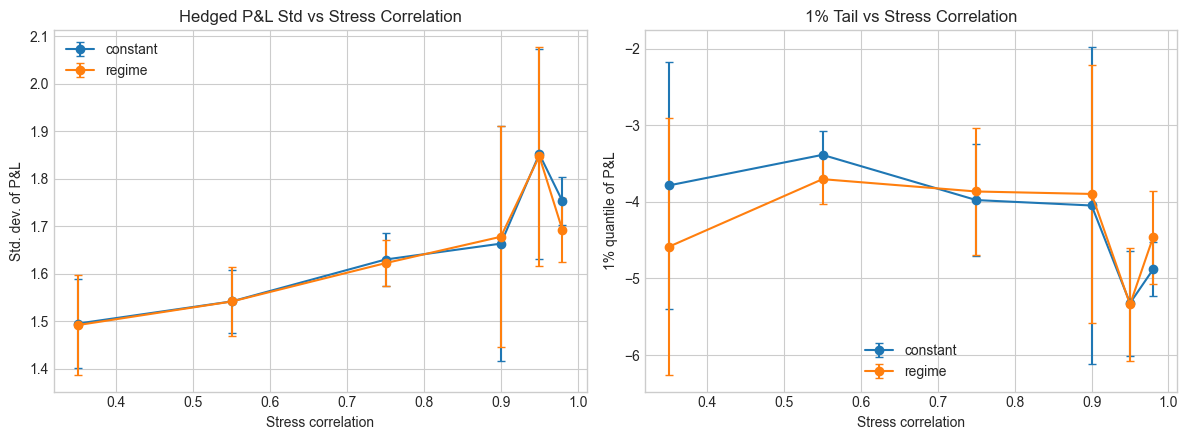

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for hedger, frame in stress_corr_summary.groupby("hedger"):
    frame = frame.sort_values("rho_stress")
    axes[0].errorbar(frame["rho_stress"], frame["avg_std_pnl"], yerr=frame["std_of_std_pnl"].fillna(0.0), marker="o", capsize=3, label=hedger)
    axes[1].errorbar(frame["rho_stress"], frame["avg_q01_pnl"], yerr=frame["std_of_q01_pnl"].fillna(0.0), marker="o", capsize=3, label=hedger)

axes[0].set_title("Hedged P&L Std vs Stress Correlation")
axes[0].set_xlabel("Stress correlation")
axes[0].set_ylabel("Std. dev. of P&L")
axes[0].legend()

axes[1].set_title("1% Tail vs Stress Correlation")
axes[1].set_xlabel("Stress correlation")
axes[1].set_ylabel("1% quantile of P&L")
axes[1].legend()

plt.tight_layout()
plt.show()

## Persistence Sweep

Here we keep the long-run stress share fixed at 20%, but vary the daily switching intensity

```math
\lambda = p_{01}+p_{10}
```

with

```math
p_{01}=0.2\lambda, \qquad p_{10}=0.8\lambda.
```

Smaller `lambda` means more persistence.

In [10]:
persistence_rows = []
for scenario_idx, lambda_daily in enumerate([0.08, 0.15, 0.25], start=1):
    p01_daily = stress_share_target * lambda_daily
    p10_daily = (1.0 - stress_share_target) * lambda_daily
    scenario_df = run_scenario(
        true_world="regime",
        hedge_models=["constant", "regime"],
        rho_constant_level=0.35,
        rho_calm_level=0.20,
        rho_stress_level=0.75,
        p01_daily=p01_daily,
        p10_daily=p10_daily,
        scenario_seed=15000 + 500 * scenario_idx,
    )
    scenario_df["lambda_daily"] = lambda_daily
    scenario_df["stress_duration_days"] = 1.0 / p10_daily
    persistence_rows.append(scenario_df)

persistence_results = pd.concat(persistence_rows, ignore_index=True)
display(persistence_results[["lambda_daily", "stress_duration_days", "hedger", "std_pnl", "q01_pnl"]].round(4))

,lambda_daily,stress_duration_days,hedger,std_pnl,q01_pnl
0,0.08,15.6250,constant,1.3788,-2.9182
1,0.08,15.6250,regime,1.3405,-3.5053
2,0.15,8.3333,constant,1.6359,-4.4945
3,0.15,8.3333,regime,1.6264,-4.8527
4,0.25,5.0000,constant,1.6668,-4.0229
5,0.25,5.0000,regime,1.6696,-4.1304


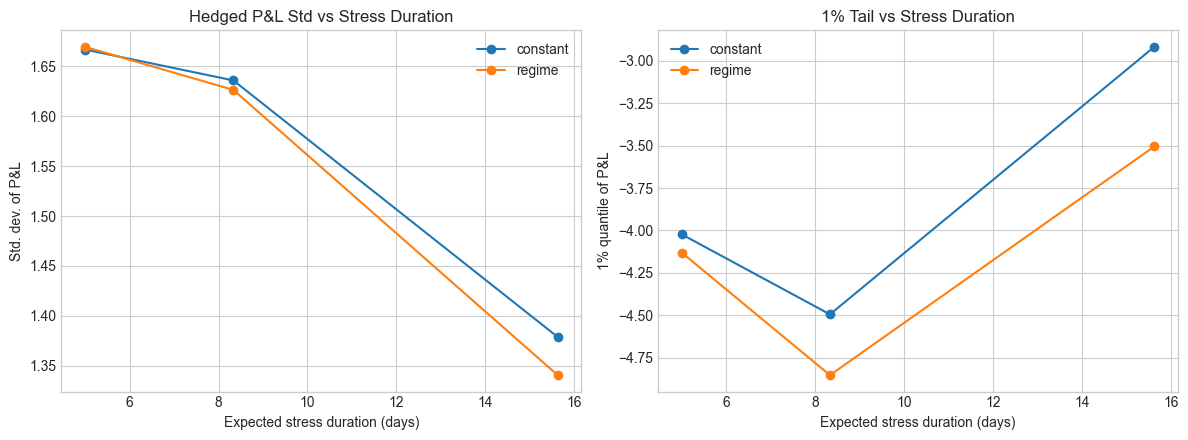

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for hedger, frame in persistence_results.groupby("hedger"):
    frame = frame.sort_values("stress_duration_days")
    axes[0].plot(frame["stress_duration_days"], frame["std_pnl"], marker="o", label=hedger)
    axes[1].plot(frame["stress_duration_days"], frame["q01_pnl"], marker="o", label=hedger)

axes[0].set_title("Hedged P&L Std vs Stress Duration")
axes[0].set_xlabel("Expected stress duration (days)")
axes[0].set_ylabel("Std. dev. of P&L")
axes[0].legend()

axes[1].set_title("1% Tail vs Stress Duration")
axes[1].set_xlabel("Expected stress duration (days)")
axes[1].set_ylabel("1% quantile of P&L")
axes[1].legend()

plt.tight_layout()
plt.show()

## Persist Outputs

In [12]:
baseline_results.to_csv(data_dir / "basket_option_sensitivity_baseline.csv", index=False)
stress_corr_results.to_csv(data_dir / "basket_option_sensitivity_stress_corr.csv", index=False)
stress_corr_summary.to_csv(data_dir / "basket_option_sensitivity_stress_corr_summary.csv", index=False)
stress_gap.to_csv(data_dir / "basket_option_sensitivity_stress_corr_gap.csv", index=False)
persistence_results.to_csv(data_dir / "basket_option_sensitivity_persistence.csv", index=False)
sensitivity_config.to_csv(data_dir / "basket_option_sensitivity_config.csv")

print(f"Saved baseline results to {data_dir / 'basket_option_sensitivity_baseline.csv'}")
print(f"Saved stress-correlation sweep to {data_dir / 'basket_option_sensitivity_stress_corr.csv'}")
print(f"Saved stress-correlation summary to {data_dir / 'basket_option_sensitivity_stress_corr_summary.csv'}")
print(f"Saved stress-correlation gap table to {data_dir / 'basket_option_sensitivity_stress_corr_gap.csv'}")
print(f"Saved persistence sweep to {data_dir / 'basket_option_sensitivity_persistence.csv'}")
print(f"Saved sensitivity config to {data_dir / 'basket_option_sensitivity_config.csv'}")

Saved baseline results to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_baseline.csv
Saved stress-correlation sweep to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_stress_corr.csv
Saved stress-correlation summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_stress_corr_summary.csv
Saved stress-correlation gap table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_stress_corr_gap.csv
Saved persistence sweep to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_persistence.csv
Saved sensitivity config to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_sensitivity_config.csv
